In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [31]:
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Extra\WGI_master_panel_final.xlsx")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Set panel index directly
df = df.set_index(['country', 'year'])

# Sort index (important for panel models)
df = df.sort_index()

print(df.head())

                  control of corruption  rule of law  \
country     year                                       
afghanistan 2004                    0.0        0.075   
            2005                    0.0        0.075   
            2006                    0.0        0.025   
            2007                    NaN          NaN   
            2008                    NaN          NaN   

                  government effectiveness  political stability  \
country     year                                                  
afghanistan 2004                      0.25               0.1875   
            2005                      0.25               0.0625   
            2006                      0.00               0.0625   
            2007                       NaN                  NaN   
            2008                       NaN                  NaN   

                  voice and accountability  regulatory quality  attacks  
country     year                                               

In [32]:
# Log transform (must for terrorism data)
df['log_attacks'] = np.log1p(df['attacks'])

# Lag variable (within each country)
df['lag_attacks'] = df.groupby(level=0)['log_attacks'].shift(1)

# Drop NA from lag
df = df.dropna()
df.head()

control of corruption  rule of law  \
country     year                                       
afghanistan 2005                    0.0        0.075   
            2006                    0.0        0.025   
            2009                    0.0        0.075   
            2010                    0.0        0.075   
            2011                    0.0        0.075   

                  government effectiveness  political stability  \
country     year                                                  
afghanistan 2005                      0.25               0.0625   
            2006                      0.00               0.0625   
            2009                      0.00               0.1250   
            2010                      0.00               0.1250   
            2011                      0.00               0.1250   

                  voice and accountability  regulatory quality  attacks  \
country     year                                                          
afghanistan 2005                  0.000000            0.107143    155.0   
            2006                  0.102000            0.107143    283.0   
            2009                  0.100667            0.107143    503.0   
            2010                  0.082667            0.107143    542.0   
            2011                  0.082667            0.107143    421.0   

                  log_attacks  lag_attacks  
country     year                            
afghanistan 2005     5.049856     4.488636  
            2006     5.648974     5.049856  
            2009     6.222576     6.028279  
            2010     6.297109     6.222576  
            2011     6.045005     6.297109

       control of corruption  rule of law  government effectiveness  \
count            2600.000000  2600.000000               2600.000000   
mean                0.329712     0.480510                  0.353173   
std                 0.269742     0.241866                  0.285928   
min                 0.000000     0.025000                  0.000000   
25%                 0.125000     0.300000                  0.250000   
50%                 0.250000     0.425000                  0.250000   
75%                 0.500000     0.650000                  0.500000   
max                 1.000000     1.000000                  1.000000   

       political stability  voice and accountability  regulatory quality  \
count          2600.000000               2600.000000         2600.000000   
mean              0.558882                  0.467540            0.496484   
std               0.244107                  0.260718            0.224479   
min               0.000000                  0.000000    

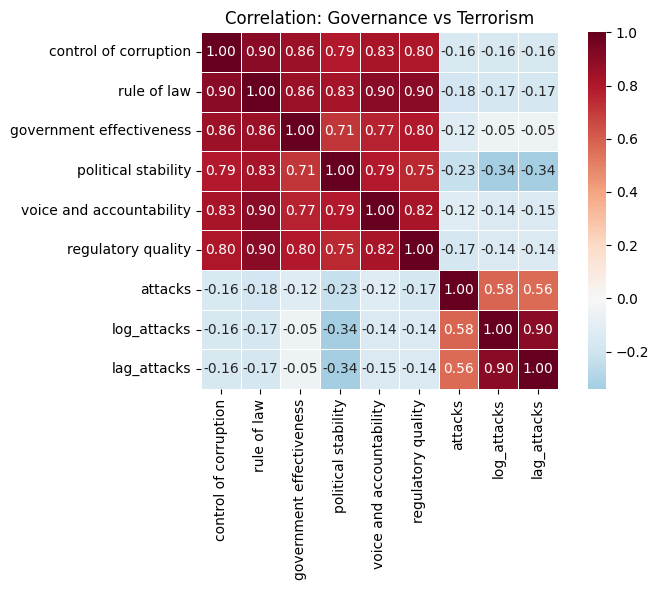

In [33]:
print(df.describe())

# Correlation heatmap
cols = [
    "control of corruption",
    "rule of law",
    "government effectiveness",
    "political stability",
    "voice and accountability",
    "regulatory quality",
    "attacks",
    "log_attacks",
    "lag_attacks"
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation: Governance vs Terrorism")
plt.tight_layout()
plt.show()

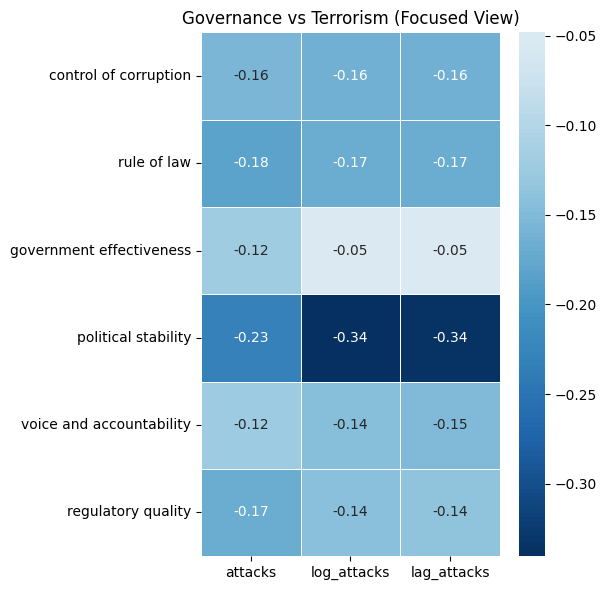

In [34]:
# Separate governance vs terrorism variables
gov_cols = [
    'control of corruption',
    'rule of law',
    'government effectiveness',
    'political stability',
    'voice and accountability',
    'regulatory quality'
]

target_cols = ['attacks','log_attacks', 'lag_attacks']

# Compute cross-correlation only
corr_matrix = df[gov_cols + target_cols].corr().loc[gov_cols, target_cols]

plt.figure(figsize=(6,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Governance vs Terrorism (Focused View)")
plt.tight_layout()
plt.show()

In [35]:
X = df[[
    "control of corruption",
    "rule of law",
    "government effectiveness",
    "political stability",
    "voice and accountability",
    "regulatory quality"
]]

X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

                   Variable        VIF
0                     const   9.690027
1     control of corruption   6.566870
2               rule of law  14.154400
3  government effectiveness   4.636356
4       political stability   3.452504
5  voice and accountability   5.391366
6        regulatory quality   5.286918


In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

gov_vars = df[['control of corruption','rule of law','government effectiveness',
               'political stability','voice and accountability','regulatory quality']]

scaler = StandardScaler()
gov_scaled = scaler.fit_transform(gov_vars)

pca = PCA(n_components=1)
df['governance_index'] = pca.fit_transform(gov_scaled)
print(pca.explained_variance_ratio_)

loadings = pd.DataFrame(pca.components_.T, 
                        columns=['PC1'], 
                        index=gov_vars.columns)
print(loadings)

[0.85158379]
                               PC1
control of corruption     0.414154
rule of law               0.431310
government effectiveness  0.399654
political stability       0.388951
voice and accountability  0.408568
regulatory quality        0.405604


In [42]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_[0])

loadings['abs_loading'] = loadings['PC1'].abs()
loadings = loadings.sort_values(by='abs_loading', ascending=False)
print(loadings)

Explained Variance Ratio: 0.8515837891449871
                               PC1  abs_loading
rule of law               0.431310     0.431310
control of corruption     0.414154     0.414154
voice and accountability  0.408568     0.408568
regulatory quality        0.405604     0.405604
government effectiveness  0.399654     0.399654
political stability       0.388951     0.388951


Principal Component Analysis (PCA) was applied to six World Governance Indicators to construct a composite governance index. The first principal component explained 85.16% of the total variance, indicating a strong common underlying factor. All indicators exhibited positive and nearly equal loadings (ranging from 0.389 to 0.431), suggesting that each dimension contributes uniformly to governance quality. Therefore, the first principal component was retained as a robust measure of overall governance.

In [48]:
import numpy as np

df=df.reset_index()

# sort before lagging
df = df.sort_values(['country', 'year'])

# create lags (panel-wise)
df['log_attack_lag1'] = df.groupby('country')['log_attack'].shift(1)
df['log_attack_lag2'] = df.groupby('country')['log_attack'].shift(2)

# drop missing values from lagging
df = df.dropna()

df = df.set_index(['country', 'year'])
df.head()

control of corruption  rule of law  \
country     year                                       
afghanistan 2013                    0.0        0.075   
            2014                    0.0        0.075   
            2015                    0.0        0.075   
            2016                    0.0        0.075   
            2017                    0.0        0.075   

                  government effectiveness  political stability  \
country     year                                                  
afghanistan 2013                       0.0                0.125   
            2014                       0.0                0.125   
            2015                       0.0                0.125   
            2016                       0.0                0.125   
            2017                       0.0                0.125   

                  voice and accountability  regulatory quality  attacks  \
country     year                                                          
afghanistan 2013                  0.082667            0.107143   1443.0   
            2014                  0.092333            0.107143   1824.0   
            2015                  0.092333            0.142857   1928.0   
            2016                  0.085000            0.142857   1616.0   
            2017                  0.085000            0.142857   1415.0   

                  log_attacks  lag_attacks  governance_index  \
country     year                                               
afghanistan 2013     7.275172     7.293018         -3.721672   
            2014     7.509335     7.275172         -3.706521   
            2015     7.564757     7.509335         -3.641977   
            2016     7.388328     7.564757         -3.653472   
            2017     7.255591     7.388328         -3.653472   

                  governance_index_norm  log_attack  log_attack_lag1  \
country     year                                                       
afghanistan 2013              -1.646134    7.275172         7.293018   
            2014              -1.639433    7.509335         7.275172   
            2015              -1.610884    7.564757         7.509335   
            2016              -1.615968    7.388328         7.564757   
            2017              -1.615968    7.255591         7.388328   

                  log_attack_lag2  
country     year                   
afghanistan 2013         6.045005  
            2014         7.293018  
            2015         7.275172  
            2016         7.509335  
            2017         7.564757

MODEL 1: All 6 Variables + Dynamic Lags

In [ ]:
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

#Define Variables
X_6 = df[['log_attack_lag1', 'log_attack_lag2',
          'rule of law','control of corruption','voice and accountability',
          'regulatory quality','government effectiveness','political stability']]

y = df['log_attack']

#Fixed Effects (Dynamic Panel)
model_fe_6 = PanelOLS(y, X_6, entity_effects=True)
fe_results_6 = model_fe_6.fit(cov_type='clustered', cluster_entity=True)

print(fe_results_6.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             log_attack   R-squared:                        0.3761
Estimator:                   PanelOLS   R-squared (Between):              0.7832
No. Observations:                1778   R-squared (Within):               0.3761
Date:                Fri, Mar 20 2026   R-squared (Overall):              0.7336
Time:                        19:15:48   Log-likelihood                   -1727.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      123.03
Entities:                         137   P-value                           0.0000
Avg Obs:                       12.978   Distribution:                  F(8,1633)
Min Obs:                       5.0000                                           
Max Obs:                       15.000   F-statistic (robust):             55.184
                            

📌 FINAL CONCLUSION (Pointer Format)

Strong persistence in terrorism
→ Both lag variables are positive and highly significant, showing that past terrorist activity strongly influences current levels.

Short-run effects dominate long-run effects
→ The first lag has a much higher coefficient than the second lag, indicating that recent events have a stronger impact than older ones.

Evidence of path dependence and self-reinforcing cycles
→ Terrorism follows a clustered pattern, where violence today increases the likelihood of violence tomorrow.

Moderate within-country explanatory power (R² ≈ 0.38)
→ The model reasonably explains changes in terrorism over time within countries.

High overall explanatory power (R² ≈ 0.73)
→ A large portion of variation across countries is captured, indicating strong cross-country differences.

Significant country-specific effects (Fixed Effects validated)
→ The model confirms that unobserved country characteristics play a crucial role in determining terrorism levels.

Multicollinearity among governance indicators
→ The high correlation between governance variables reduces the reliability of individual coefficient estimates.

Need for a composite governance measure (PCA)
→ A single governance index provides a more stable and interpretable representation of institutional quality.

Policy implication: Long-term interventions are necessary
→ Since terrorism is persistent, short-term policies are insufficient; sustained governance improvements are essential.

In [51]:
#Random Effects
model_re_6 = RandomEffects(y, X_6)
re_results_6 = model_re_6.fit()

print(re_results_6.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             log_attack   R-squared:                        0.9080
Estimator:              RandomEffects   R-squared (Between):              0.9934
No. Observations:                1778   R-squared (Within):               0.2768
Date:                Fri, Mar 20 2026   R-squared (Overall):              0.9080
Time:                        19:17:30   Log-likelihood                   -1910.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2182.9
Entities:                         137   P-value                           0.0000
Avg Obs:                       12.978   Distribution:                  F(8,1770)
Min Obs:                       5.0000                                           
Max Obs:                       15.000   F-statistic (robust):             2182.9
                            

MODEL 2: PCA Governance Index + Dynamic Lags

In [53]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

gov_vars = df[['rule of law','control of corruption','voice and accountability',
               'regulatory quality','government effectiveness','political stability']]

scaler = StandardScaler()
gov_scaled = scaler.fit_transform(gov_vars)

pca = PCA(n_components=1)
df['governance_index'] = pca.fit_transform(gov_scaled)

#Define Variables
X_pca = df[['log_attack_lag1', 'log_attack_lag2', 'governance_index']]
y = df['log_attack']

#Fixed Effects (Dynamic)
model_fe_pca = PanelOLS(y, X_pca, entity_effects=True)
fe_results_pca = model_fe_pca.fit(cov_type='clustered', cluster_entity=True)

print(fe_results_pca.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             log_attack   R-squared:                        0.3628
Estimator:                   PanelOLS   R-squared (Between):              0.8621
No. Observations:                1778   R-squared (Within):               0.3628
Date:                Fri, Mar 20 2026   R-squared (Overall):              0.7990
Time:                        19:21:42   Log-likelihood                   -1746.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      310.86
Entities:                         137   P-value                           0.0000
Avg Obs:                       12.978   Distribution:                  F(3,1638)
Min Obs:                       5.0000                                           
Max Obs:                       15.000   F-statistic (robust):             124.84
                            

In [54]:
#Random Effects
model_re_pca = RandomEffects(y, X_pca)
re_results_pca = model_re_pca.fit()

print(re_results_pca.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             log_attack   R-squared:                        0.9064
Estimator:              RandomEffects   R-squared (Between):              0.9938
No. Observations:                1778   R-squared (Within):               0.2616
Date:                Fri, Mar 20 2026   R-squared (Overall):              0.9064
Time:                        19:21:53   Log-likelihood                   -1926.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      5727.5
Entities:                         137   P-value                           0.0000
Avg Obs:                       12.978   Distribution:                  F(3,1775)
Min Obs:                       5.0000                                           
Max Obs:                       15.000   F-statistic (robust):             5727.5
                            